In [1]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

C:\Users\leona\AppData\Local\Temp\ipykernel_19424\3560671651.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# Load Data

df = pd.read_csv("../data/cafe_orders_dataset.csv")
df.head()

,OrderID,CustomerName,CoffeeType,Quantity,TotalPrice($),OrderTime,PaymentMethod,StoreLocation
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,Joshua,Latte,3,13.5,2024-11-30 07:12:11.627286,Cash,Lake Joyside
1,0822e8f3-6c03-4199-972a-846916419f82,Anthony,Mocha,1,5.0,2024-11-29 11:10:20.393124,Cash,New Jamesside
2,96da1dac-72ff-4d2a-b86e-cbe06b65a6a4,Joshua,Americano,3,10.5,2025-03-28 05:23:08.609217,Cash,Lake Roberto
3,f50bea63-371e-4d7b-a7cd-813047229389,Kathryn,Latte,3,13.5,2024-11-08 05:09:47.259523,Mobile Payment,Davisstad
4,0b1f9163-ce9f-457f-83b7-a3a69a8dca03,Jessica,Iced Latte,1,5.0,2025-01-26 10:22:10.148200,Cash,Millerport


In [3]:
# EDA (Exploratory Data Analysis)

sns.set_theme(style="whitegrid")

C:\Users\leona\AppData\Local\Temp\ipykernel_19424\3305911058.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='CoffeeType', order=df['CoffeeType'].value_counts().index, palette='viridis')


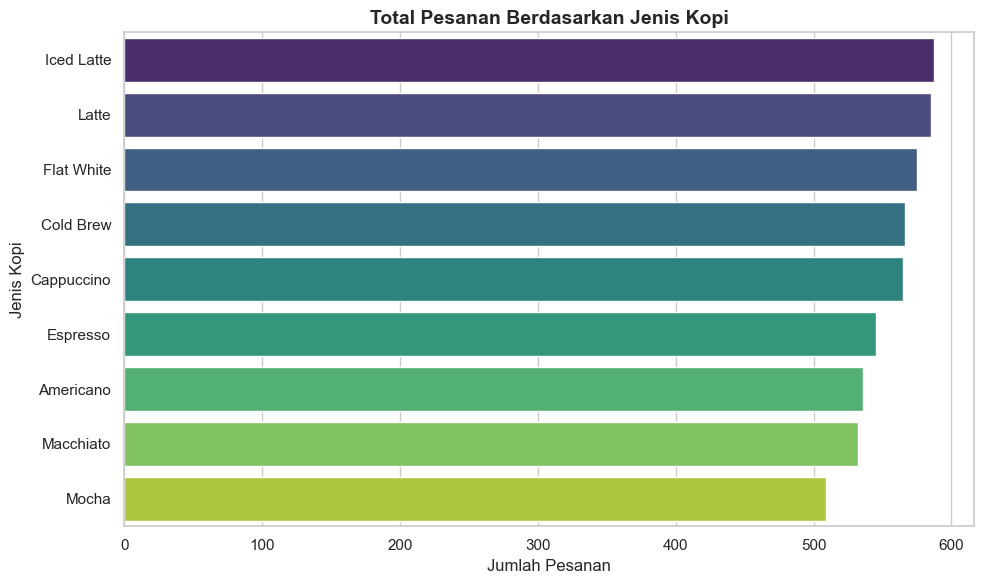

In [4]:
# 1. Distribusi Jenis Kopi
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='CoffeeType', order=df['CoffeeType'].value_counts().index, palette='viridis')
plt.title('Total Pesanan Berdasarkan Jenis Kopi', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Pesanan')
plt.ylabel('Jenis Kopi')
plt.tight_layout()
plt.show()

C:\Users\leona\AppData\Local\Temp\ipykernel_19424\3124784331.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_per_coffee.values, y=revenue_per_coffee.index, palette='magma')


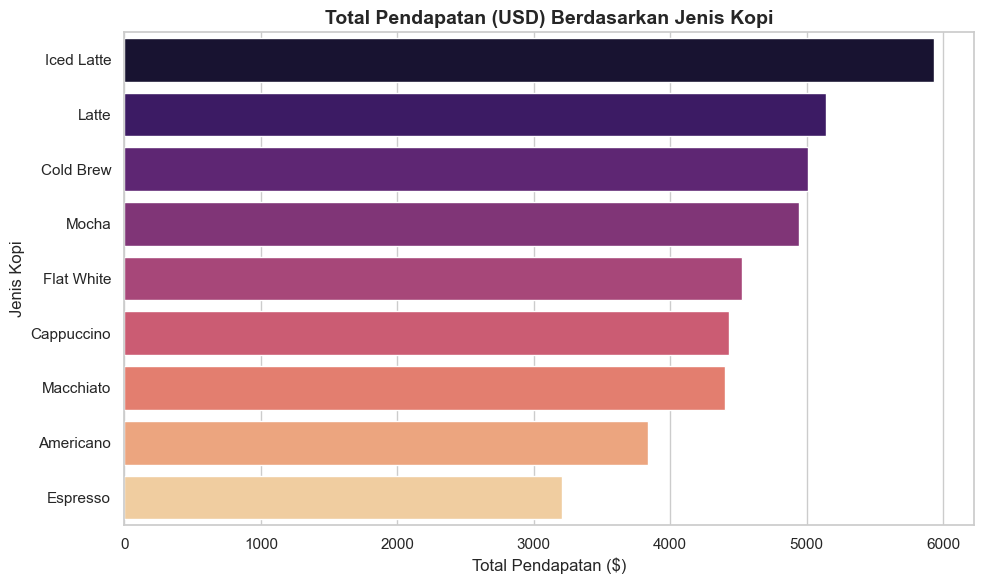

In [6]:
# 2. Total Pendapatan per Jenis Kopi
plt.figure(figsize=(10, 6))
revenue_per_coffee = df.groupby('CoffeeType')['TotalPrice($)'].sum().sort_values(ascending=False)
sns.barplot(x=revenue_per_coffee.values, y=revenue_per_coffee.index, palette='magma')
plt.title('Total Pendapatan (USD) Berdasarkan Jenis Kopi', fontsize=14, fontweight='bold')
plt.xlabel('Total Pendapatan ($)')
plt.ylabel('Jenis Kopi')
plt.tight_layout()
plt.show()

C:\Users\leona\AppData\Local\Temp\ipykernel_19424\1314722498.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='PaymentMethod', order=df['PaymentMethod'].value_counts().index, palette='pastel')


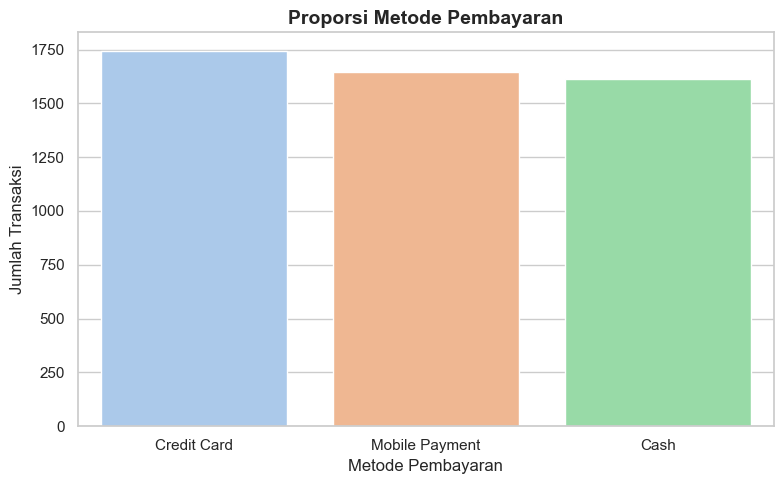

In [7]:
# 3. Distribusi Metode Pembayaran
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='PaymentMethod', order=df['PaymentMethod'].value_counts().index, palette='pastel')
plt.title('Proporsi Metode Pembayaran', fontsize=14, fontweight='bold')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Jumlah Transaksi')
plt.tight_layout()
plt.show()

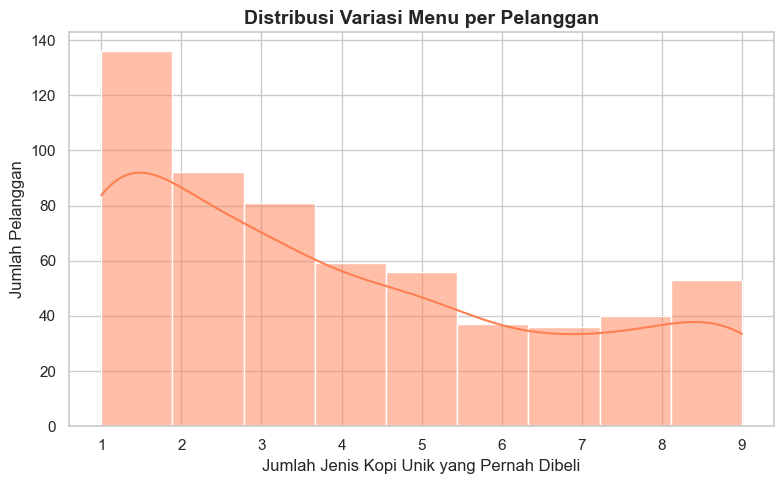

In [8]:
# 4. Variasi Menu per Pelanggan
plt.figure(figsize=(8, 5))
items_per_customer = df.groupby('CustomerName')['CoffeeType'].nunique()
sns.histplot(items_per_customer, bins=9, kde=True, color='coral')
plt.title('Distribusi Variasi Menu per Pelanggan', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Jenis Kopi Unik yang Pernah Dibeli')
plt.ylabel('Jumlah Pelanggan')
plt.tight_layout()
plt.show()

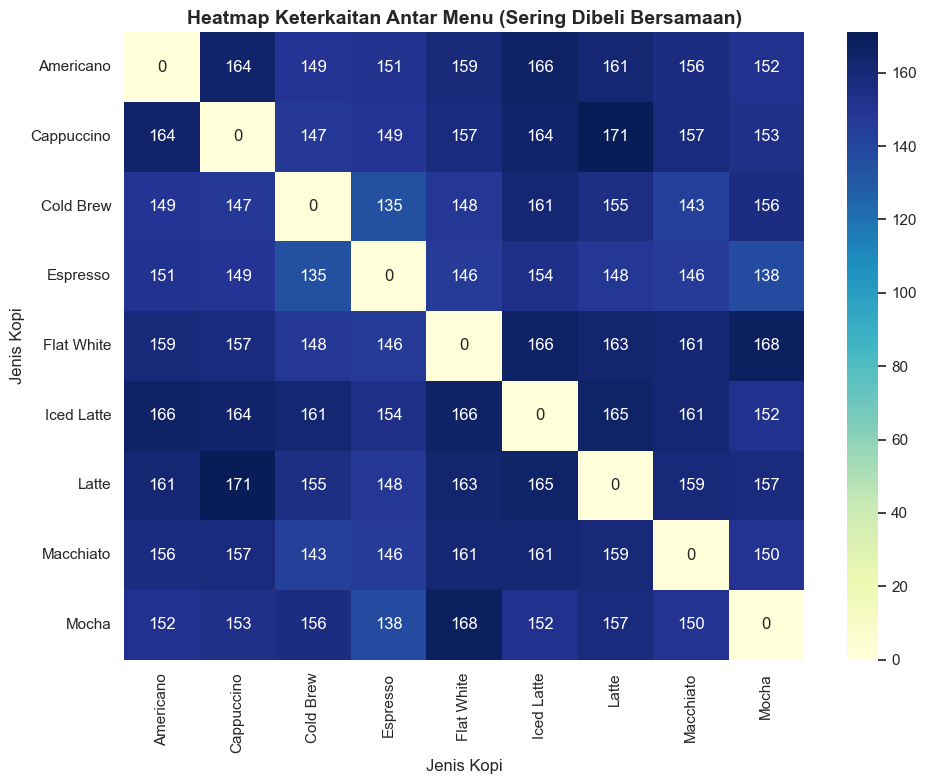

In [9]:
# 5. Heatmap Co-Occurence
plt.figure(figsize=(10, 8))
item_user_matrix = pd.crosstab(df['CoffeeType'], df['CustomerName']).clip(upper=1)
co_occurrence = item_user_matrix.dot(item_user_matrix.T)
np.fill_diagonal(co_occurrence.values, 0) # Mengosongkan diagonal agar warna jelas

sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Heatmap Keterkaitan Antar Menu (Sering Dibeli Bersamaan)', fontsize=14, fontweight='bold')
plt.xlabel('Jenis Kopi')
plt.ylabel('Jenis Kopi')
plt.tight_layout()
plt.show()